In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
train_data = pd.read_csv('/Users/wingyuenyau/Downloads/train (1).csv')

## Dict
Pclass = Ticket class (1:upper, 2:middle, 3:lower) \
SibSp = no. of siblings \
Parch = no. of children/parents \
Embarked = Port of embarkation

In [3]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# EDA, Data preprocessing

In [4]:
train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Findings
38.4% survived \
Age's mean is near to median, not skew \
Fare's mean is much larger than median, right-tail

In [5]:
train_data.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
train_data.isna().sum()
# need to handle Age, Cabin and Embarked

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
train_data['Title'] = train_data['Name'].str.extract(r'\,(.*?)\.')
title_mapping = {
    ' Mr': 'Mr',
    ' Mrs': 'Mrs',
    ' Miss': 'Miss',
    ' Master': 'Master',
    ' Don': 'Rare',
    ' Rev': 'Rare',
    ' Dr': 'Rare',
    ' Mme': 'Mrs',
    ' Ms': 'Miss',
    ' Major': 'Rare',
    ' Lady': 'Rare',
    ' Sir': 'Rare',
    ' Mlle': 'Miss',
    ' Col': 'Rare',
    ' Capt': 'Rare',
    ' the Countess': 'Rare',
    ' Jonkheer': 'Rare'
}
# map the normalized titles to the current titles 
train_data.Title = train_data.Title.map(title_mapping)


In [8]:
train_data.Title.unique()
#Confirmation

array(['Mr', 'Mrs', 'Miss', 'Master', 'Rare'], dtype=object)

In [9]:
#cabin has 687 null, drop whole column
#PassengerID, Name, Ticket are not useful
train_data = train_data.drop(columns = ['PassengerId','Name','Ticket','Cabin'])

In [10]:
train_data['Embarked'] = train_data['Embarked'].fillna(train_data['Embarked'].mode()[0])

In [11]:
train_data['Age'] = train_data['Age'].fillna(train_data['Age'].median())

In [12]:
#Check again null value
train_data.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
Title       0
dtype: int64

In [13]:
# Add family size as feature to replace SibSp and Parch
train_data['FamilySize'] = 1+train_data.SibSp+train_data.Parch

In [14]:
# Add IsAlone as feature
train_data['IsAlone'] = train_data['FamilySize'].apply(lambda x : 1 if x ==1 else 0)

In [15]:
# group age into bin
train_data['AgeBin'] = pd.cut(
    train_data['Age'],
    bins=[0,10,20,30,40,50,60,80])

In [16]:
#Check logic
train_data[(train_data.IsAlone == 1 )& (train_data.FamilySize != 1)]

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,IsAlone,AgeBin


# Survival Rate by features

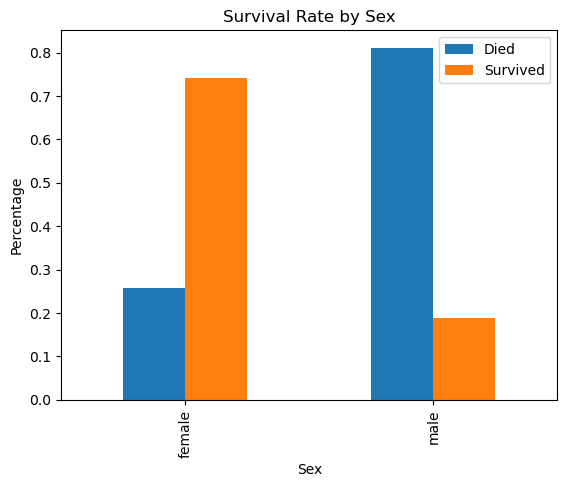

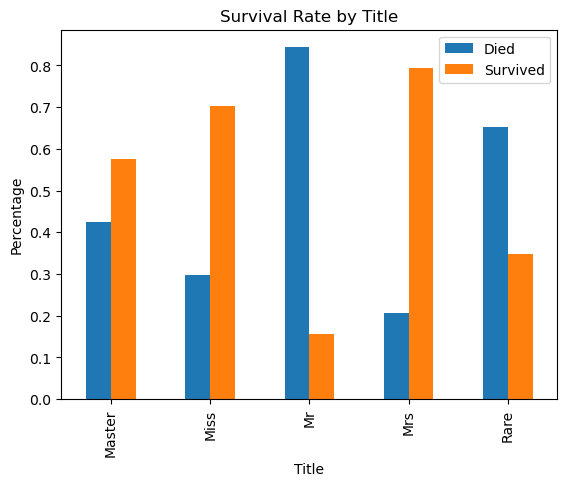

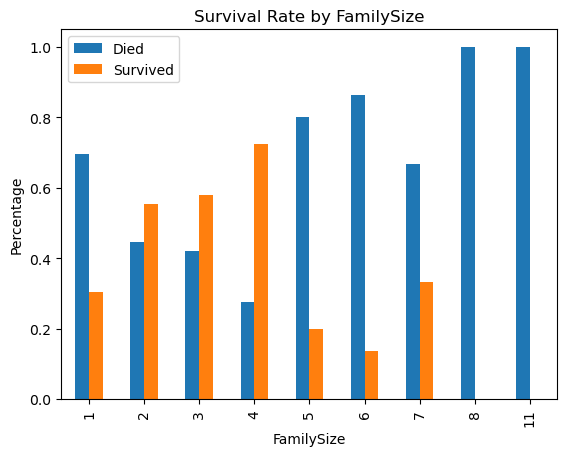

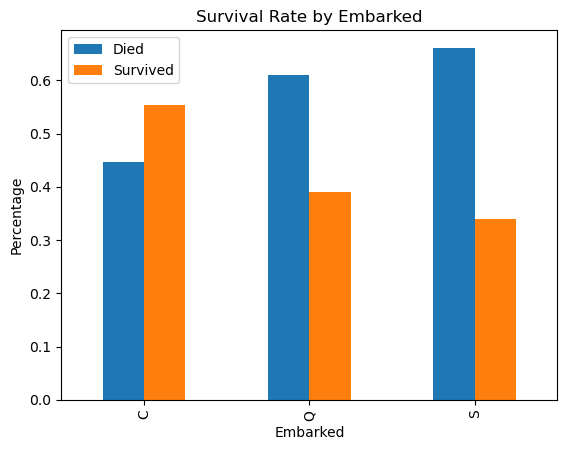

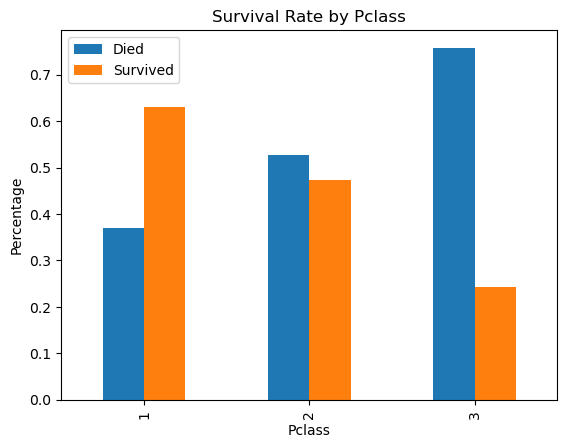

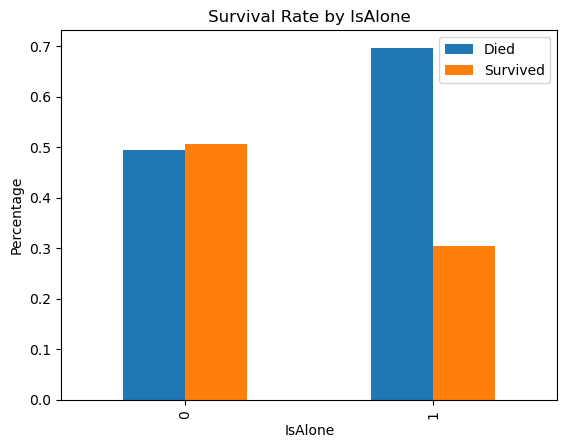

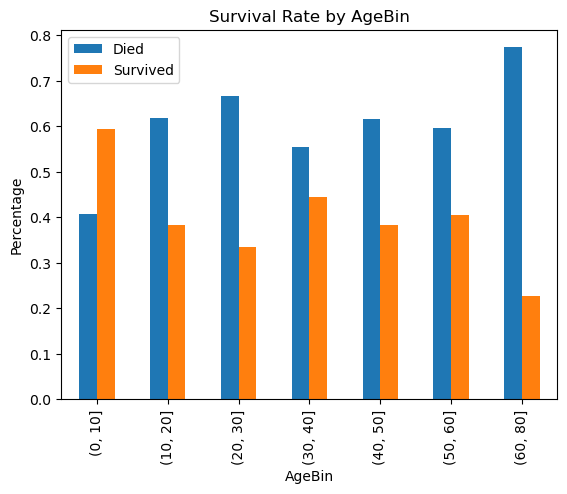

In [17]:
for col in ['Sex','Title','FamilySize','Embarked','Pclass','IsAlone','AgeBin']:
    survival_rate = pd.crosstab(
        train_data['{}'.format(col)],
        train_data['Survived'],
        normalize='index'
    )
    
    survival_rate.plot(kind='bar')
    plt.title('Survival Rate by {}'.format(col))
    plt.xlabel('{}'.format(col))
    plt.ylabel('Percentage')
    plt.legend(['Died','Survived'])
    plt.show()

# Result
Woman, Master, Family size of 2,3,4, Embarked at C, Pclass of 1, age <= 10 \
show higher survial rate  has higher survial rate


# Encode categoric column and rescale numeric column

In [18]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

In [26]:
#Encoding categorical values
encoder = LabelEncoder()
train_data['Sex'] = encoder.fit_transform(train_data['Sex'])
train_data['Embarked'] = encoder.fit_transform(train_data['Embarked'])
train_data['Title'] = encoder.fit_transform(train_data['Title'])


In [19]:
scaler = MinMaxScaler()
train_data[['Age','Fare']] = scaler.fit_transform(train_data[['Age','Fare']])

In [20]:
train_data = train_data.drop(columns = ['SibSp','Parch','AgeBin'])

In [28]:
train_data

,Survived,Pclass,Sex,Age,Fare,Embarked,Title,FamilySize,IsAlone
0,0,3,1,0.271174,0.014151,2,2,2,0
1,1,1,0,0.472229,0.139136,0,3,2,0
2,1,3,0,0.321438,0.015469,2,1,1,1
3,1,1,0,0.434531,0.103644,2,3,2,0
4,0,3,1,0.434531,0.015713,2,2,1,1
...,...,...,...,...,...,...,...,...,...
886,0,2,1,0.334004,0.025374,2,4,1,1
887,1,1,0,0.233476,0.058556,2,1,1,1
888,0,3,0,0.346569,0.045771,2,1,4,0
889,1,1,1,0.321438,0.058556,0,2,1,1


# Train model

In [29]:
X = train_data.iloc[ : , 1:]
y = train_data.iloc[ : , 0]

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2)

In [32]:
#LogisticRegression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
acc_log = round(logreg.score(X_train, y_train) * 100, 3)
log = round(logreg.score(X_test, y_test) * 100, 3)
print("Train: ", acc_log)
print("Test: ", log)

Train:  80.618
Test:  79.33


In [33]:
#RandomForestClassifier
RF = RandomForestClassifier(
    max_features='sqrt',
    min_samples_leaf=5,
    min_samples_split=10,
    n_estimators=100,
    max_depth=5
    ,random_state = 42
)
RF.fit(X_train, y_train)
acc_random_forest = round(RF.score(X_train, y_train) * 100, 3) 
random_forest = round(RF.score(X_test, y_test) * 100, 3) 
print("Train: ", acc_random_forest)
print("Test: ", random_forest)

Train:  83.708
Test:  84.358


# Cross Validation

In [34]:
from sklearn.model_selection import cross_val_score
# Random Forest CV
scores = cross_val_score(
    RF,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print(scores.mean())

print(scores.std())

0.8294080723118448
0.018635462863280133


In [39]:
#Logistic regression CV
scores = cross_val_score(
    logreg,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print(scores.mean())

print(scores.std())

0.7935408951101626
0.023126376372649426


# Model selection
- Random Forest achieved 82.9% of mean cross-validation accuracy with SD of 1.9%
- survival affected by complex interactions among sex, pclass, family size, which is not linear relationship
- pick RF

Text(70.72222222222221, 0.5, 'Truth')

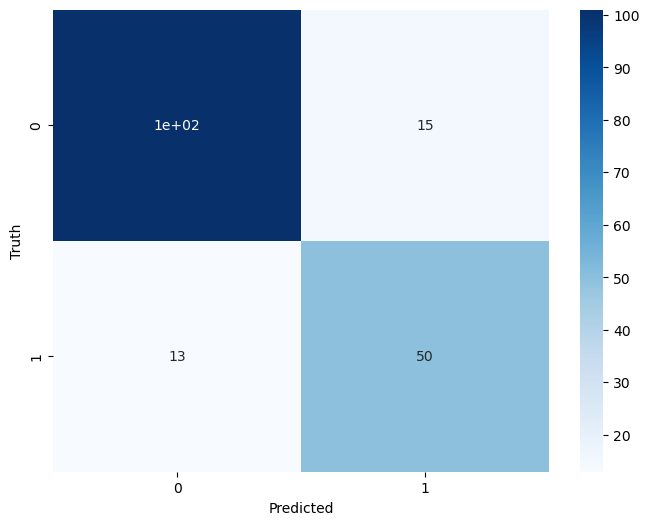

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

y_predicted = RF.predict(X_test)
cm = confusion_matrix(y_test, y_predicted)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True,cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Truth')

# Prediction result
- In reality 115 people died, 100 people can be correctly predicted 
- 63 people died, 50 can be correctly predicted
- 113 people predicted to be dead, 100 is correct
- 65 people predicted to be survied, 50 is correct

In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_predicted))
#Precision = TP/(TP+FP)
#Recall = TP/(TP+FN)

              precision    recall  f1-score   support

           0       0.89      0.87      0.88       116
           1       0.77      0.79      0.78        63

    accuracy                           0.84       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179



### Precision was higher for the non-survivor class (89%) than for the survivor class (77%)
- suggesting that predictions of death were more reliable 
- macro F1-score of 0.83 indicates that the model performed consistently across both classes rather than relying on the majority class

In [37]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': RF.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
1,Sex,0.393975
5,Title,0.191435
3,Fare,0.126496
0,Pclass,0.115361
2,Age,0.067173
6,FamilySize,0.065204
4,Embarked,0.024358
7,IsAlone,0.015998


In [38]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    RF,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42
)

importance = pd.Series(
    result.importances_mean,
    index=X.columns
).sort_values(ascending=False)

print(importance)


Sex           0.120391
FamilySize    0.040503
Pclass        0.038547
Title         0.031564
Age           0.008659
Fare          0.005028
Embarked      0.004749
IsAlone       0.003911
dtype: float64


# Findings
1.Sex consistently remained as the most important feature \
2.Family size carries unique information that cannot replaced by other features \
3.Fare adds very little unique predictive power when pclass and other features are available \
4. Title is important but overlapped with Sex and age \
5. Sex, FamilySize, Pclass, Title are important features which sync with findings in EDA \
6. Can drop Embarked/IsAlone for next training
